Using device: cuda
Stage 1 model: /kaggle/input/datasets/gwaceee/miccai-dataset/source_domain_model_final.pth
Stage 2 MMD:   /kaggle/input/datasets/gwaceee/miccai-data2/stage2_mmd_results.json

From Stage 2:
  LoRA layers (high shift):  [4, 7, 8, 9, 10, 11]
  Frozen layers (low shift): [0, 1, 2, 3, 5, 6]

Loading Lacuna dataset:
Lacuna full dataset: 2747 images | Parasitized: 2018 | Uninfected: 729
Lacuna full dataset: 2747 images | Parasitized: 2018 | Uninfected: 729

Fixed validation set: 200 samples (held out for all experiments)
Available for training: 2547 samples

STAGE 3: Comparative Fine-Tuning Experiments
Strategies: ['Full Fine-Tuning', 'Standard LoRA (all layers)', 'DS-Aware LoRA (ours)']
Data sizes: [10, 20, 50, 100, 200]
Total runs: 15

────────────────────────────────────────────────────────────
Data size: n=10 training samples
────────────────────────────────────────────────────────────

Run 1/15: Full Fine-Tuning

  [full] n=10
    Trainable params: 85,800,194 / 85,800,

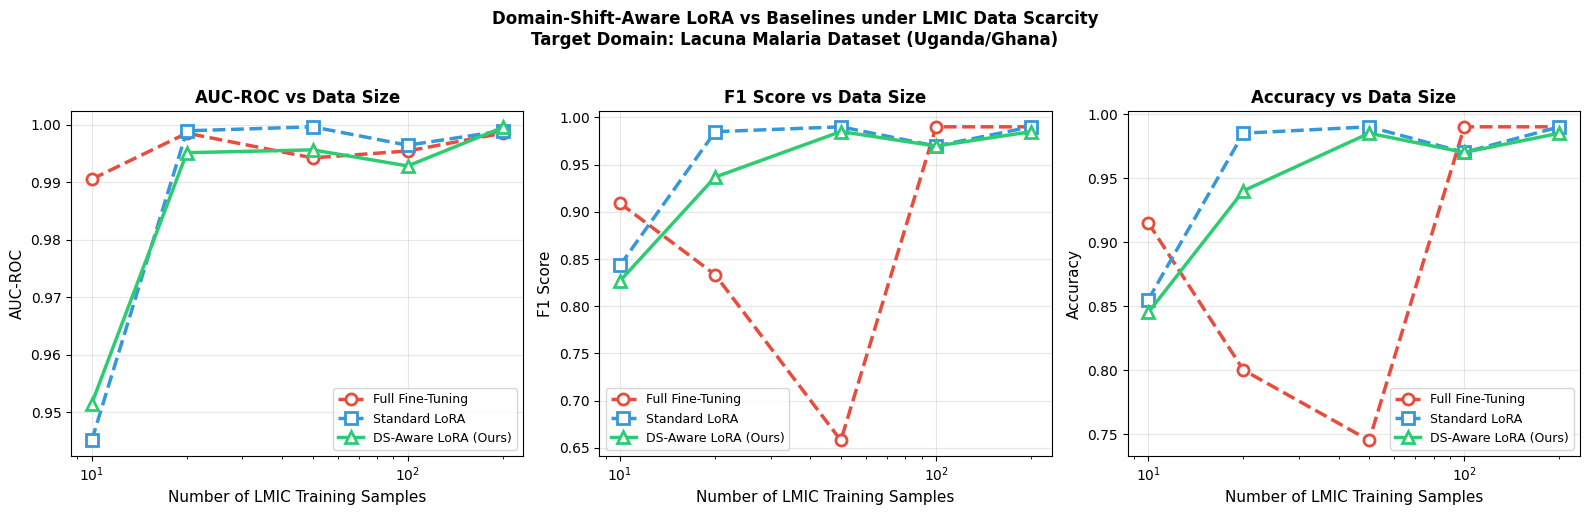


Main results figure saved to: /kaggle/working/stage3_main_results.png

PARAMETER EFFICIENCY
                      trainable_params  trainable_pct
DS-Aware LoRA (Ours)           3638786           4.24
Full FT                       85800194         100.00
Standard LoRA                  7274498           8.46

(This goes in Table 2 of your paper)

STAGE 3 COMPLETE

Files saved to /kaggle/working/:
  stage3_results.csv       — all experiment results
  stage3_main_results.png  — Figure 2 of your paper

Key question to answer from your results:
  At n=10 and n=20, does DS-Aware LoRA maintain higher AUC
  than Standard LoRA and Full Fine-Tuning?
  If yes — your method works. That is your paper's main claim.

Next step: Stage 4 — Ablation study


In [1]:
# =============================================================================
# STAGE 3: Comparative Fine-Tuning Experiments
# Domain-Shift-Aware LoRA for Malaria Detection in LMIC Settings
#
# What this notebook does:
#   Compares three fine-tuning strategies on the Lacuna (LMIC) dataset
#   under increasing data scarcity:
#
#   Strategy A — Full Fine-Tuning:       all 85M parameters updated
#   Strategy B — Standard LoRA:          LoRA on all 12 layers uniformly
#   Strategy C — Domain-Shift-Aware LoRA: LoRA only on high-MMD layers (8,9,10,11)
#
#   Each strategy is evaluated at 5 data sizes: 10, 20, 50, 100, 200 samples
#   Metrics: AUC-ROC, F1, Accuracy
#
#   This produces the main results table of your paper.
#
# Estimated runtime: ~3-4 hours on Kaggle T4 (15 experiments total)
# =============================================================================


# ── 0. IMPORTS ────────────────────────────────────────────────────────────────

import os, json, random, copy
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
import timm

from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── 1. REPRODUCIBILITY + GPU CHECK ───────────────────────────────────────────

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if str(DEVICE) == "cpu":
    raise RuntimeError("Enable GPU: Session options → Accelerator → GPU T4 x2")

# ── 2. PATHS ──────────────────────────────────────────────────────────────────

import kagglehub
nih_path    = kagglehub.dataset_download("shahriar26s/malaria-detection")
lacuna_path = kagglehub.dataset_download("rajsahu2004/lacuna-malaria-detection-dataset")

# Auto-find Stage 1 model and Stage 2 MMD results
STAGE1_MODEL_PATH = None
STAGE2_JSON_PATH  = None

for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full = os.path.join(root, f)
        if f == 'source_domain_model_final.pth':
            STAGE1_MODEL_PATH = full
        if f == 'stage2_mmd_results.json':
            STAGE2_JSON_PATH = full

if STAGE1_MODEL_PATH is None:
    raise FileNotFoundError("source_domain_model_final.pth not found in /kaggle/input")
if STAGE2_JSON_PATH is None:
    raise FileNotFoundError("stage2_mmd_results.json not found in /kaggle/input")

print(f"Stage 1 model: {STAGE1_MODEL_PATH}")
print(f"Stage 2 MMD:   {STAGE2_JSON_PATH}")

OUTPUT_DIR = '/kaggle/working/'

# ── 3. LOAD MMD RESULTS ───────────────────────────────────────────────────────

with open(STAGE2_JSON_PATH, 'r') as f:
    mmd_results = json.load(f)

LORA_LAYERS   = mmd_results['lora_layers']   # e.g. [8, 9, 10, 11]
FROZEN_LAYERS = mmd_results['frozen_layers']
MMD_SCORES    = mmd_results['mmd_scores']

print(f"\nFrom Stage 2:")
print(f"  LoRA layers (high shift):  {LORA_LAYERS}")
print(f"  Frozen layers (low shift): {FROZEN_LAYERS}")


# ── 4. DATASET ────────────────────────────────────────────────────────────────

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class LacunaDataset(Dataset):
    """
    Full Lacuna dataset with image-level binary labels.
    Trophozoite present → Parasitized (1)
    NEG / WBC only     → Uninfected (0)
    """
    def __init__(self, csv_path, img_dir, transform=None):
        self.transform = transform
        self.img_dir   = Path(img_dir)

        df = pd.read_csv(csv_path)
        image_labels = df.groupby('Image_ID')['class'].apply(
            lambda x: 1 if (x == 'Trophozoite').any() else 0
        ).reset_index()
        image_labels.columns = ['Image_ID', 'label']

        existing = set(os.listdir(self.img_dir))
        image_labels = image_labels[image_labels['Image_ID'].isin(existing)]
        self.samples = list(zip(image_labels['Image_ID'], image_labels['label']))

        pos = sum(1 for _, l in self.samples if l == 1)
        neg = sum(1 for _, l in self.samples if l == 0)
        print(f"Lacuna full dataset: {len(self.samples)} images "
              f"| Parasitized: {pos} | Uninfected: {neg}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_id, label = self.samples[idx]
        image = Image.open(self.img_dir / img_id).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

    def get_balanced_indices(self, n, seed=42):
        """
        Return indices for a balanced subset of n samples (n/2 per class).
        Used to simulate few-shot LMIC data scarcity.
        """
        random.seed(seed)
        pos_idx = [i for i, (_, l) in enumerate(self.samples) if l == 1]
        neg_idx = [i for i, (_, l) in enumerate(self.samples) if l == 0]
        n_each  = n // 2
        if len(pos_idx) < n_each or len(neg_idx) < n_each:
            raise ValueError(
                f"Not enough samples: need {n_each} per class, "
                f"have {len(pos_idx)} pos and {len(neg_idx)} neg"
            )
        return (random.sample(pos_idx, n_each) +
                random.sample(neg_idx, n_each))


def find_split_dir(base_path, split_name):
    for p in Path(base_path).rglob('*'):
        if p.is_dir() and p.name.lower() == split_name.lower():
            if len([d for d in p.iterdir() if d.is_dir()]) >= 2:
                return p
    return None


class NIHDataset(Dataset):
    """NIH dataset for evaluation on source domain (optional reference)."""
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.samples   = []
        valid_ext = {'.jpg', '.jpeg', '.png'}
        for folder in Path(root_dir).iterdir():
            if not folder.is_dir(): continue
            name = folder.name.lower()
            label = 1 if 'parasit' in name else 0 if 'uninfect' in name else None
            if label is None: continue
            for img_path in folder.iterdir():
                if img_path.suffix.lower() in valid_ext:
                    self.samples.append((str(img_path), label))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, label


# Load full Lacuna dataset (we'll sample subsets from this)
print("\nLoading Lacuna dataset:")
lacuna_full = LacunaDataset(
    csv_path=f"{lacuna_path}/Train.csv",
    img_dir=f"{lacuna_path}/images",
    transform=train_transform
)

# Lacuna validation set — hold out 200 samples, never used for training
# This is fixed across ALL experiments for fair comparison
VAL_INDICES = lacuna_full.get_balanced_indices(n=200, seed=999)
ALL_INDICES = set(range(len(lacuna_full)))
TRAINABLE_INDICES = list(ALL_INDICES - set(VAL_INDICES))

lacuna_val = Subset(
    LacunaDataset(f"{lacuna_path}/Train.csv",
                  f"{lacuna_path}/images",
                  transform=val_transform),
    VAL_INDICES
)
val_loader = DataLoader(lacuna_val, batch_size=32, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f"\nFixed validation set: {len(VAL_INDICES)} samples (held out for all experiments)")
print(f"Available for training: {len(TRAINABLE_INDICES)} samples")


# ── 5. LORA IMPLEMENTATION ────────────────────────────────────────────────────

class LoRALinear(nn.Module):
    """
    LoRA adapter for a linear layer.
    Adds low-rank matrices A and B such that:
        output = W*x + (B @ A) * x * (alpha / rank)

    Only A and B are trained. W is frozen.
    """
    def __init__(self, linear_layer, rank=4, alpha=8):
        super().__init__()
        in_features  = linear_layer.in_features
        out_features = linear_layer.out_features

        self.linear = linear_layer  # frozen original weights
        self.rank   = rank
        self.alpha  = alpha
        self.scale  = alpha / rank

        # LoRA matrices — small and trainable
        self.lora_A = nn.Parameter(torch.randn(rank, in_features) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank))

    def forward(self, x):
        base_out = self.linear(x)
        lora_out = (x @ self.lora_A.T) @ self.lora_B.T
        return base_out + lora_out * self.scale


def apply_lora_to_model(model, target_layers, rank=4, alpha=8):
    """
    Apply LoRA adapters to Q and V projection matrices
    in the specified transformer blocks.

    Args:
        model:         ViT model
        target_layers: list of block indices to apply LoRA to
        rank:          LoRA rank
        alpha:         LoRA scaling factor

    Returns:
        model with LoRA applied, parameter counts
    """
    # First freeze ALL parameters
    for param in model.parameters():
        param.requires_grad = False

    # Always keep classification head trainable
    for param in model.head.parameters():
        param.requires_grad = True

    lora_param_count = 0

    for block_idx in target_layers:
        block = model.blocks[block_idx]
        attn  = block.attn

        # Get the fused QKV projection
        # timm ViT uses a single qkv linear layer: [3*hidden, hidden]
        # We replace it with LoRA-wrapped version
        if hasattr(attn, 'qkv'):
            original_qkv = attn.qkv
            lora_qkv = LoRALinear(original_qkv, rank=rank, alpha=alpha)
            attn.qkv = lora_qkv
            lora_params = sum(p.numel() for p in lora_qkv.parameters()
                              if p.requires_grad)
            lora_param_count += lora_params

        # Also make the attention projection trainable
        if hasattr(attn, 'proj'):
            for param in attn.proj.parameters():
                param.requires_grad = True
                lora_param_count += param.numel()

        # Layer norm in this block
        for param in block.norm1.parameters():
            param.requires_grad = True
        for param in block.norm2.parameters():
            param.requires_grad = True

    # Final layer norm
    for param in model.norm.parameters():
        param.requires_grad = True

    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters()
                           if p.requires_grad)

    return model, total_params, trainable_params


def apply_full_finetuning(model):
    """Unfreeze all parameters for full fine-tuning."""
    for param in model.parameters():
        param.requires_grad = True
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return model, total, trainable


# ── 6. TRAINING & EVALUATION FUNCTIONS ───────────────────────────────────────

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        all_preds.extend(torch.argmax(outputs, 1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), accuracy_score(all_labels, all_preds)


def evaluate(model, loader, device):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs   = torch.softmax(outputs, 1)[:, 1].cpu().numpy()
            preds   = torch.argmax(outputs, 1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    classes = set(all_labels)
    if len(classes) < 2:
        return accuracy_score(all_labels, all_preds), \
               f1_score(all_labels, all_preds, average='binary', zero_division=0), \
               float('nan')

    return (accuracy_score(all_labels, all_preds),
            f1_score(all_labels, all_preds, average='binary'),
            roc_auc_score(all_labels, all_probs))


def run_experiment(strategy_name, n_samples, source_model_path,
                   trainable_indices, val_loader, device,
                   lora_layers=None, rank=4, alpha=8,
                   epochs=15, lr=1e-4, seed=42):
    """
    Run one fine-tuning experiment.

    Args:
        strategy_name:     'full', 'standard_lora', 'ds_aware_lora'
        n_samples:         number of Lacuna training samples
        source_model_path: path to Stage 1 model
        trainable_indices: pool of available training indices
        val_loader:        fixed validation loader
        lora_layers:       which layers to apply LoRA to (None = all for standard)
        rank, alpha:       LoRA hyperparameters
        epochs:            training epochs
        lr:                learning rate

    Returns:
        dict of results
    """
    print(f"\n  [{strategy_name}] n={n_samples}")

    # ── Load fresh model ──
    model = timm.create_model('vit_base_patch16_224',
                              pretrained=False, num_classes=2)
    checkpoint = torch.load(source_model_path, map_location=device,
                            weights_only=False)
    model.load_state_dict(checkpoint['model_state'])

    # ── Apply strategy ──
    if strategy_name == 'full':
        model, total, trainable = apply_full_finetuning(model)
    elif strategy_name == 'standard_lora':
        all_layers = list(range(12))
        model, total, trainable = apply_lora_to_model(
            model, all_layers, rank=rank, alpha=alpha)
    elif strategy_name == 'ds_aware_lora':
        model, total, trainable = apply_lora_to_model(
            model, lora_layers, rank=rank, alpha=alpha)

    model = model.to(device)
    pct   = 100 * trainable / total
    print(f"    Trainable params: {trainable:,} / {total:,} ({pct:.2f}%)")

    # ── Sample training data ──
    random.seed(seed)

    # Get labels for trainable pool
    lacuna_base = LacunaDataset(
        f"{lacuna_path}/Train.csv",
        f"{lacuna_path}/images",
        transform=train_transform
    )
    pool_labels = [lacuna_base.samples[i][1] for i in trainable_indices]
    pos_pool = [trainable_indices[i] for i, l in enumerate(pool_labels) if l == 1]
    neg_pool = [trainable_indices[i] for i, l in enumerate(pool_labels) if l == 0]

    n_each       = n_samples // 2
    train_indices = (random.sample(pos_pool, min(n_each, len(pos_pool))) +
                     random.sample(neg_pool, min(n_each, len(neg_pool))))

    train_subset = Subset(lacuna_base, train_indices)
    train_loader = DataLoader(train_subset, batch_size=min(16, n_samples),
                              shuffle=True, num_workers=2, pin_memory=True)

    # ── Training setup ──
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-7)

    # ── Training loop ──
    best_auc   = 0.0
    best_state = None

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device)
        val_acc, val_f1, val_auc = evaluate(model, val_loader, device)
        scheduler.step()

        if not np.isnan(val_auc) and val_auc > best_auc:
            best_auc   = val_auc
            best_state = copy.deepcopy(model.state_dict())

        if epoch % 5 == 0:
            print(f"    Epoch {epoch}/{epochs} | "
                  f"Train Acc: {train_acc:.3f} | "
                  f"Val AUC: {val_auc:.4f}")

    # ── Final evaluation with best model ──
    if best_state is not None:
        model.load_state_dict(best_state)

    final_acc, final_f1, final_auc = evaluate(model, val_loader, device)

    print(f"    → Final: Acc={final_acc:.4f} | F1={final_f1:.4f} | "
          f"AUC={final_auc:.4f}")

    return {
        'strategy':   strategy_name,
        'n_samples':  n_samples,
        'accuracy':   final_acc,
        'f1':         final_f1,
        'auc':        final_auc,
        'trainable_params': trainable,
        'trainable_pct':    pct,
    }


# ── 7. MAIN EXPERIMENT LOOP ───────────────────────────────────────────────────

DATA_SIZES = [10, 20, 50, 100, 200]

STRATEGIES = [
    ('full',           'Full Fine-Tuning',          None),
    ('standard_lora',  'Standard LoRA (all layers)', list(range(12))),
    ('ds_aware_lora',  'DS-Aware LoRA (ours)',       LORA_LAYERS),
]

print("\n" + "="*60)
print("STAGE 3: Comparative Fine-Tuning Experiments")
print("="*60)
print(f"Strategies: {[s[1] for s in STRATEGIES]}")
print(f"Data sizes: {DATA_SIZES}")
print(f"Total runs: {len(STRATEGIES) * len(DATA_SIZES)}")
print("="*60)

all_results = []
run_count   = 0
total_runs  = len(STRATEGIES) * len(DATA_SIZES)

for n_samples in DATA_SIZES:
    print(f"\n{'─'*60}")
    print(f"Data size: n={n_samples} training samples")
    print(f"{'─'*60}")

    for strategy_key, strategy_name, lora_layers in STRATEGIES:
        run_count += 1
        print(f"\nRun {run_count}/{total_runs}: {strategy_name}")

        result = run_experiment(
            strategy_name    = strategy_key,
            n_samples        = n_samples,
            source_model_path= STAGE1_MODEL_PATH,
            trainable_indices= TRAINABLE_INDICES,
            val_loader       = val_loader,
            device           = DEVICE,
            lora_layers      = lora_layers,
            rank             = 4,
            alpha            = 8,
            epochs           = 15,
            lr               = 1e-4,
            seed             = SEED,
        )
        all_results.append(result)

        # Save after every run — so you don't lose results if Kaggle times out
        results_df = pd.DataFrame(all_results)
        results_df.to_csv(os.path.join(OUTPUT_DIR, 'stage3_results.csv'),
                          index=False)


# ── 8. RESULTS TABLE ──────────────────────────────────────────────────────────

results_df = pd.DataFrame(all_results)

print("\n" + "="*60)
print("MAIN RESULTS TABLE")
print("="*60)

# Pivot for clean display
for metric in ['auc', 'f1', 'accuracy']:
    pivot = results_df.pivot(
        index='n_samples', columns='strategy', values=metric
    )
    # Reorder columns
    col_order = ['full', 'standard_lora', 'ds_aware_lora']
    pivot = pivot[[c for c in col_order if c in pivot.columns]]
    pivot.columns = ['Full FT', 'Standard LoRA', 'DS-Aware LoRA (Ours)']
    print(f"\n{metric.upper()} Scores:")
    print(pivot.round(4).to_string())


# ── 9. VISUALISATION — MAIN PAPER FIGURES ────────────────────────────────────

strategy_display = {
    'full':          ('Full Fine-Tuning',         '#e74c3c', 'o--'),
    'standard_lora': ('Standard LoRA',             '#3498db', 's--'),
    'ds_aware_lora': ('DS-Aware LoRA (Ours)',      '#2ecc71', '^-'),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics   = [('auc', 'AUC-ROC'), ('f1', 'F1 Score'), ('accuracy', 'Accuracy')]

for ax, (metric_key, metric_label) in zip(axes, metrics):
    for strategy_key, (label, color, style) in strategy_display.items():
        subset = results_df[results_df['strategy'] == strategy_key]
        subset = subset.sort_values('n_samples')
        ax.plot(subset['n_samples'], subset[metric_key],
                style, color=color, label=label,
                linewidth=2.5, markersize=8, markerfacecolor='white',
                markeredgewidth=2)

    ax.set_xlabel('Number of LMIC Training Samples', fontsize=11)
    ax.set_ylabel(metric_label, fontsize=11)
    ax.set_title(f'{metric_label} vs Data Size', fontsize=12, fontweight='bold')
    ax.set_xticks(DATA_SIZES)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')

plt.suptitle(
    'Domain-Shift-Aware LoRA vs Baselines under LMIC Data Scarcity\n'
    'Target Domain: Lacuna Malaria Dataset (Uganda/Ghana)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, 'stage3_main_results.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"\nMain results figure saved to: {fig_path}")


# ── 10. PARAMETER EFFICIENCY TABLE ────────────────────────────────────────────

print("\n" + "="*60)
print("PARAMETER EFFICIENCY")
print("="*60)

param_summary = results_df.groupby('strategy')[
    ['trainable_params', 'trainable_pct']].first()
param_summary.index = ['DS-Aware LoRA (Ours)', 'Full FT', 'Standard LoRA']
print(param_summary.round(2).to_string())
print("\n(This goes in Table 2 of your paper)")


# ── 11. FINAL SUMMARY ─────────────────────────────────────────────────────────

print("\n" + "="*60)
print("STAGE 3 COMPLETE")
print("="*60)
print(f"\nFiles saved to {OUTPUT_DIR}:")
print(f"  stage3_results.csv       — all experiment results")
print(f"  stage3_main_results.png  — Figure 2 of your paper")
print(f"\nKey question to answer from your results:")
print(f"  At n=10 and n=20, does DS-Aware LoRA maintain higher AUC")
print(f"  than Standard LoRA and Full Fine-Tuning?")
print(f"  If yes — your method works. That is your paper's main claim.")
print(f"\nNext step: Stage 4 — Ablation study")